In [1]:
%matplotlib inline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from random import randint

import matplotlib.pyplot as plt

# Rendu TP scoring
Chai Yulin, Pagano Lucas

### Chargement et préparation des données

On charge les données dans un dataframe, on le mélange car on ne sait pas comment il était ordonné au préalable, et on vérifie que les classes sont équilibrées.

In [2]:
file = "wave5000.data"
data = pd.read_csv(file, header=None)
#On mélange le dataset
data.sample(frac=1).reset_index(inplace=True, drop=True)
data[21].value_counts()

2    1696
0    1657
1    1647
Name: 21, dtype: int64

On sépare le jeu de données en test et train, en respectant la proportion des classes.

In [3]:
train, test = train_test_split(data, stratify=data.iloc[:, 21], train_size=0.8)
nb_features = len(data.columns) - 1
train_x = train.values[:, :nb_features]
train_y = train.values[:, -1]
test_x = test.values[:, :nb_features]
test_y = test.values[:, -1]

/home/lucas/.local/lib/python3.6/site-packages/sklearn/model_selection/_split.py:2026: FutureWarning: From version 0.21, test_size will always complement train_size unless both are specified.
  FutureWarning)


On calcule le taux de réussite.

In [5]:
clf = DecisionTreeClassifier(min_samples_split=20)
clf.fit(train_x, train_y)
predict = clf.predict(test_x)
taux_reussite = sum(predict == test_y) / len(predict)
print("Taux de réussite : {}".format(taux_reussite))

Taux de réussite : 0.746


On s'intéresse à la prédiction de la classe 1, donc on met les autres classes à 0. On recrée les jeux d'entraînement et de test étant donné que les données ont changé.

In [10]:
data[data[21] == 2] = 0
train, test = train_test_split(data, stratify=data.iloc[:, 21], train_size=0.8)
nb_features = len(data.columns) - 1
train_x = train.values[:, :nb_features]
train_y = train.values[:, -1]
test_x = test.values[:, :nb_features]
test_y = test.values[:, -1]

/home/lucas/.local/lib/python3.6/site-packages/sklearn/model_selection/_split.py:2026: FutureWarning: From version 0.21, test_size will always complement train_size unless both are specified.
  FutureWarning)


### Matrice de confusion

On apprend sur les données d'entraînement, on calcule la matrice de confusion puis la précision, le rappel, la sensibilité et la spécificité. On cherche à prédire la classe "1" donc la colonne 0 de la matrice de confusion représente les négatifs.

In [11]:
clf = DecisionTreeClassifier(min_samples_split=20)
clf.fit(train_x, train_y)
predict = clf.predict(test_x)
conf_matrix = confusion_matrix(y_true=test_y, y_pred=predict)
tn, fp, fn, tp = conf_matrix.ravel()

confiance = tp / (tp + fp)
rappel = tp / (tp + fn)
sensibilite = tp / (tp + fn)
specificite = tn / (tn + fp)

print("Confiance : {}".format(confiance))
print("Rappel : {}".format(rappel))
print("Sensibilité : {}".format(sensibilite))
print("Spécificité : {}".format(specificite))

Confiance : 1.0
Rappel : 1.0
Sensibilité : 1.0
Spécificité : 1.0


On vérifie avec les mesures de scikit learn :

In [8]:
sklearn_rappel = recall_score(y_true=test_y, y_pred=predict)
sklearn_precision = precision_score(y_true=test_y, y_pred=predict)

print("Rappel sklearn: {}".format(sklearn_rappel))
print("Precision sklearn (<=> confiance): {}".format(sklearn_precision))

Rappel sklearn: 1.0
Precision sklearn (<=> confiance): 1.0


### Courbes ROC

On affiche des courbes ROC sur le jeu d'entraînement et le jeu de test.

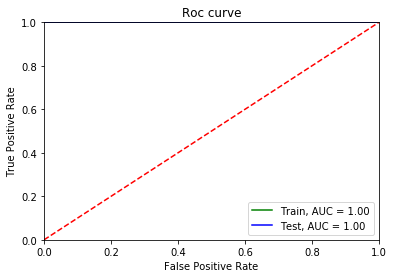

In [9]:
probas_train = clf.predict_proba(train_x)
probas_test = clf.predict_proba(test_x)
fpr_train, tpr_train, _ = roc_curve(y_true=train_y, y_score=probas_train[:,1])
fpr_test, tpr_test, _ = roc_curve(y_true=test_y, y_score=probas_test[:,1])
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)
plt.title("Roc curve")
plt.plot(fpr_train, tpr_train, 'g', label='Train, AUC = %0.2f' % roc_auc_train)
plt.plot(fpr_test, tpr_test, 'b', label='Test, AUC = %0.2f' % roc_auc_test)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()